In [23]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [24]:
df = pd.read_csv('data/diabetes_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,TinglingHandsFeet,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,6000,44,0,1,2,1,32.985284,1,4.499365,2.443385,...,1,73.765109,0,0,0,1.782724,4.486980,7.211349,1,Confidential
1,6001,51,1,0,1,2,39.916764,0,1.578919,8.301264,...,0,91.445753,0,0,1,3.381070,5.961705,5.024612,1,Confidential
2,6002,89,1,0,1,3,19.782251,0,1.177301,6.103395,...,0,54.485744,0,0,0,2.701019,8.950821,7.034944,0,Confidential
3,6003,21,1,1,1,2,32.376881,1,1.714621,8.645465,...,0,77.866758,0,0,1,1.409056,3.124769,4.717774,0,Confidential
4,6004,27,1,0,1,3,16.808600,0,15.462549,4.629383,...,0,37.731808,0,0,0,1.218452,6.977741,7.887940,0,Confidential


In [28]:
# Patient ID and Doctor In Charge are not useful for prediction, so we drop them
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True, errors='ignore')

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1879.0,55.043108,20.515839,20.000000,38.000000,55.000000,73.000000,90.000000
Gender,1879.0,0.487493,0.499977,0.000000,0.000000,0.000000,1.000000,1.000000
Ethnicity,1879.0,0.755721,1.047558,0.000000,0.000000,0.000000,1.000000,3.000000
SocioeconomicStatus,1879.0,0.992017,0.764940,0.000000,0.000000,1.000000,2.000000,2.000000
EducationLevel,1879.0,1.699308,0.885665,0.000000,1.000000,2.000000,2.000000,3.000000
BMI,1879.0,27.687601,7.190975,15.025898,21.469981,27.722988,33.856460,39.998811
Smoking,1879.0,0.281533,0.449866,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,1879.0,10.096587,5.914216,0.000928,4.789725,10.173865,15.285359,19.996231
PhysicalActivity,1879.0,5.200790,2.857012,0.004089,2.751022,5.249002,7.671402,9.993893
DietQuality,1879.0,4.895801,2.867144,0.000885,2.476802,4.888566,7.356058,9.998677


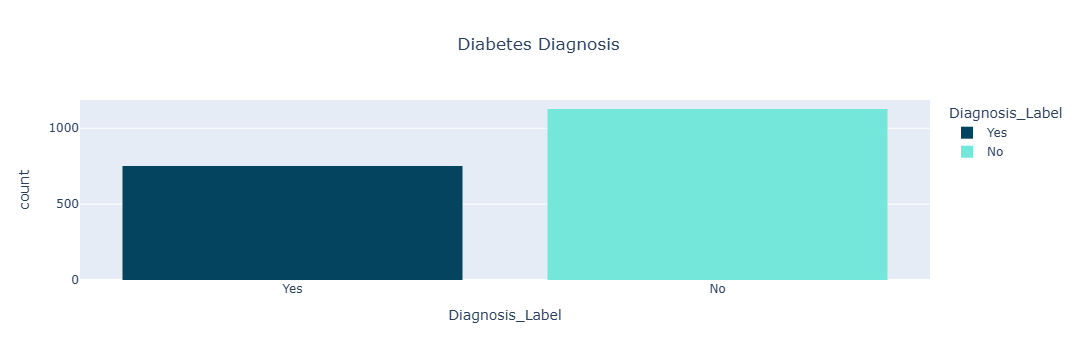

In [30]:
df['Diagnosis_Label'] = df['Diagnosis'].map({0: 'No', 1: 'Yes'})

fig = px.histogram(
    data_frame=df,
    x='Diagnosis_Label',
    color='Diagnosis_Label',
    color_discrete_sequence=['#05445E', '#75E6DA'],
    title='Diabetes Diagnosis'
)

fig.update_layout(title_x=0.5)
fig.write_image('plots/diabetes_diagnosis.png')
fig.show()

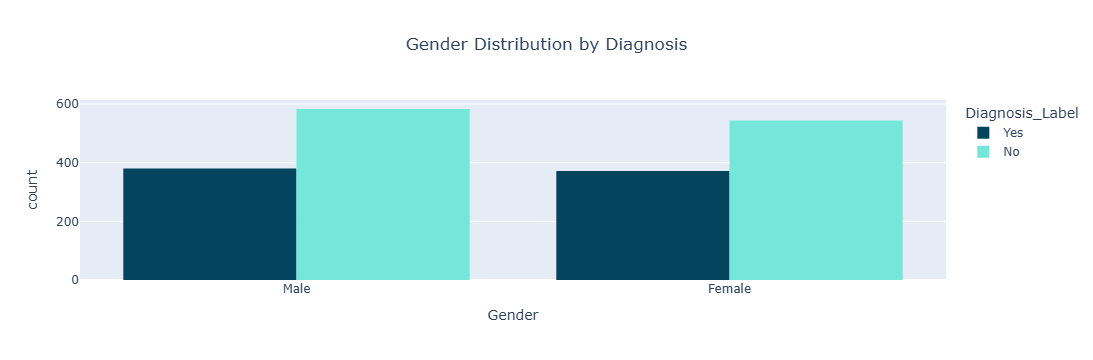

In [31]:
df['Gender_Label'] = df['Gender'].map({0: 'Male', 1: 'Female'})

fig = px.histogram(
    data_frame=df,
    x='Gender_Label',
    color='Diagnosis_Label',
    barmode='group',
    color_discrete_sequence=['#05445E', '#75E6DA'],
    title='Gender Distribution by Diagnosis'
)

fig.update_layout(title_x=0.5, xaxis_title='Gender')
fig.write_image('plots/gender_by_diagnosis.png')
fig.show()

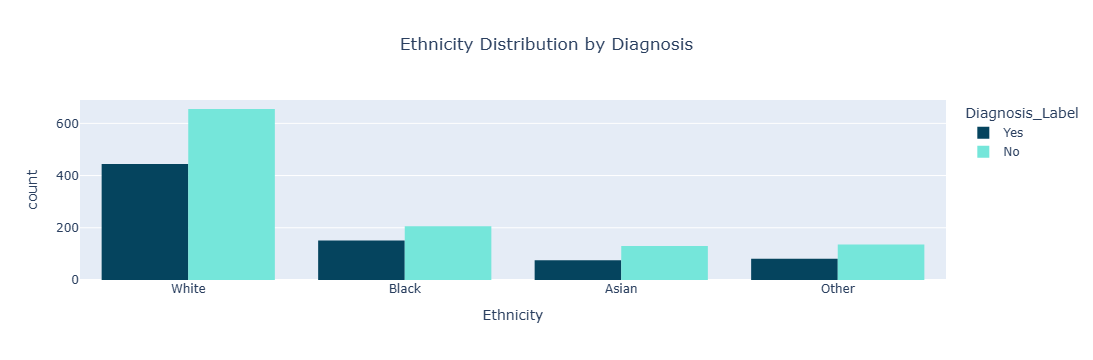

In [32]:
df['Ethnicity_Label'] = df['Ethnicity'].map({0: 'White', 1: 'Black', 2: 'Asian', 3: 'Other'})

fig = px.histogram(
    data_frame=df,
    x='Ethnicity_Label',
    color='Diagnosis_Label',
    barmode='group',
    color_discrete_sequence=['#05445E', '#75E6DA'],
    title='Ethnicity Distribution by Diagnosis',
    category_orders={'Ethnicity_Label': ['White', 'Black', 'Asian', 'Other']}
)

fig.update_layout(title_x=0.5, xaxis_title='Ethnicity')
fig.write_image('plots/ethnicity_by_diagnosis.png')
fig.show()

In [34]:
corr = df.corr(numeric_only=True)

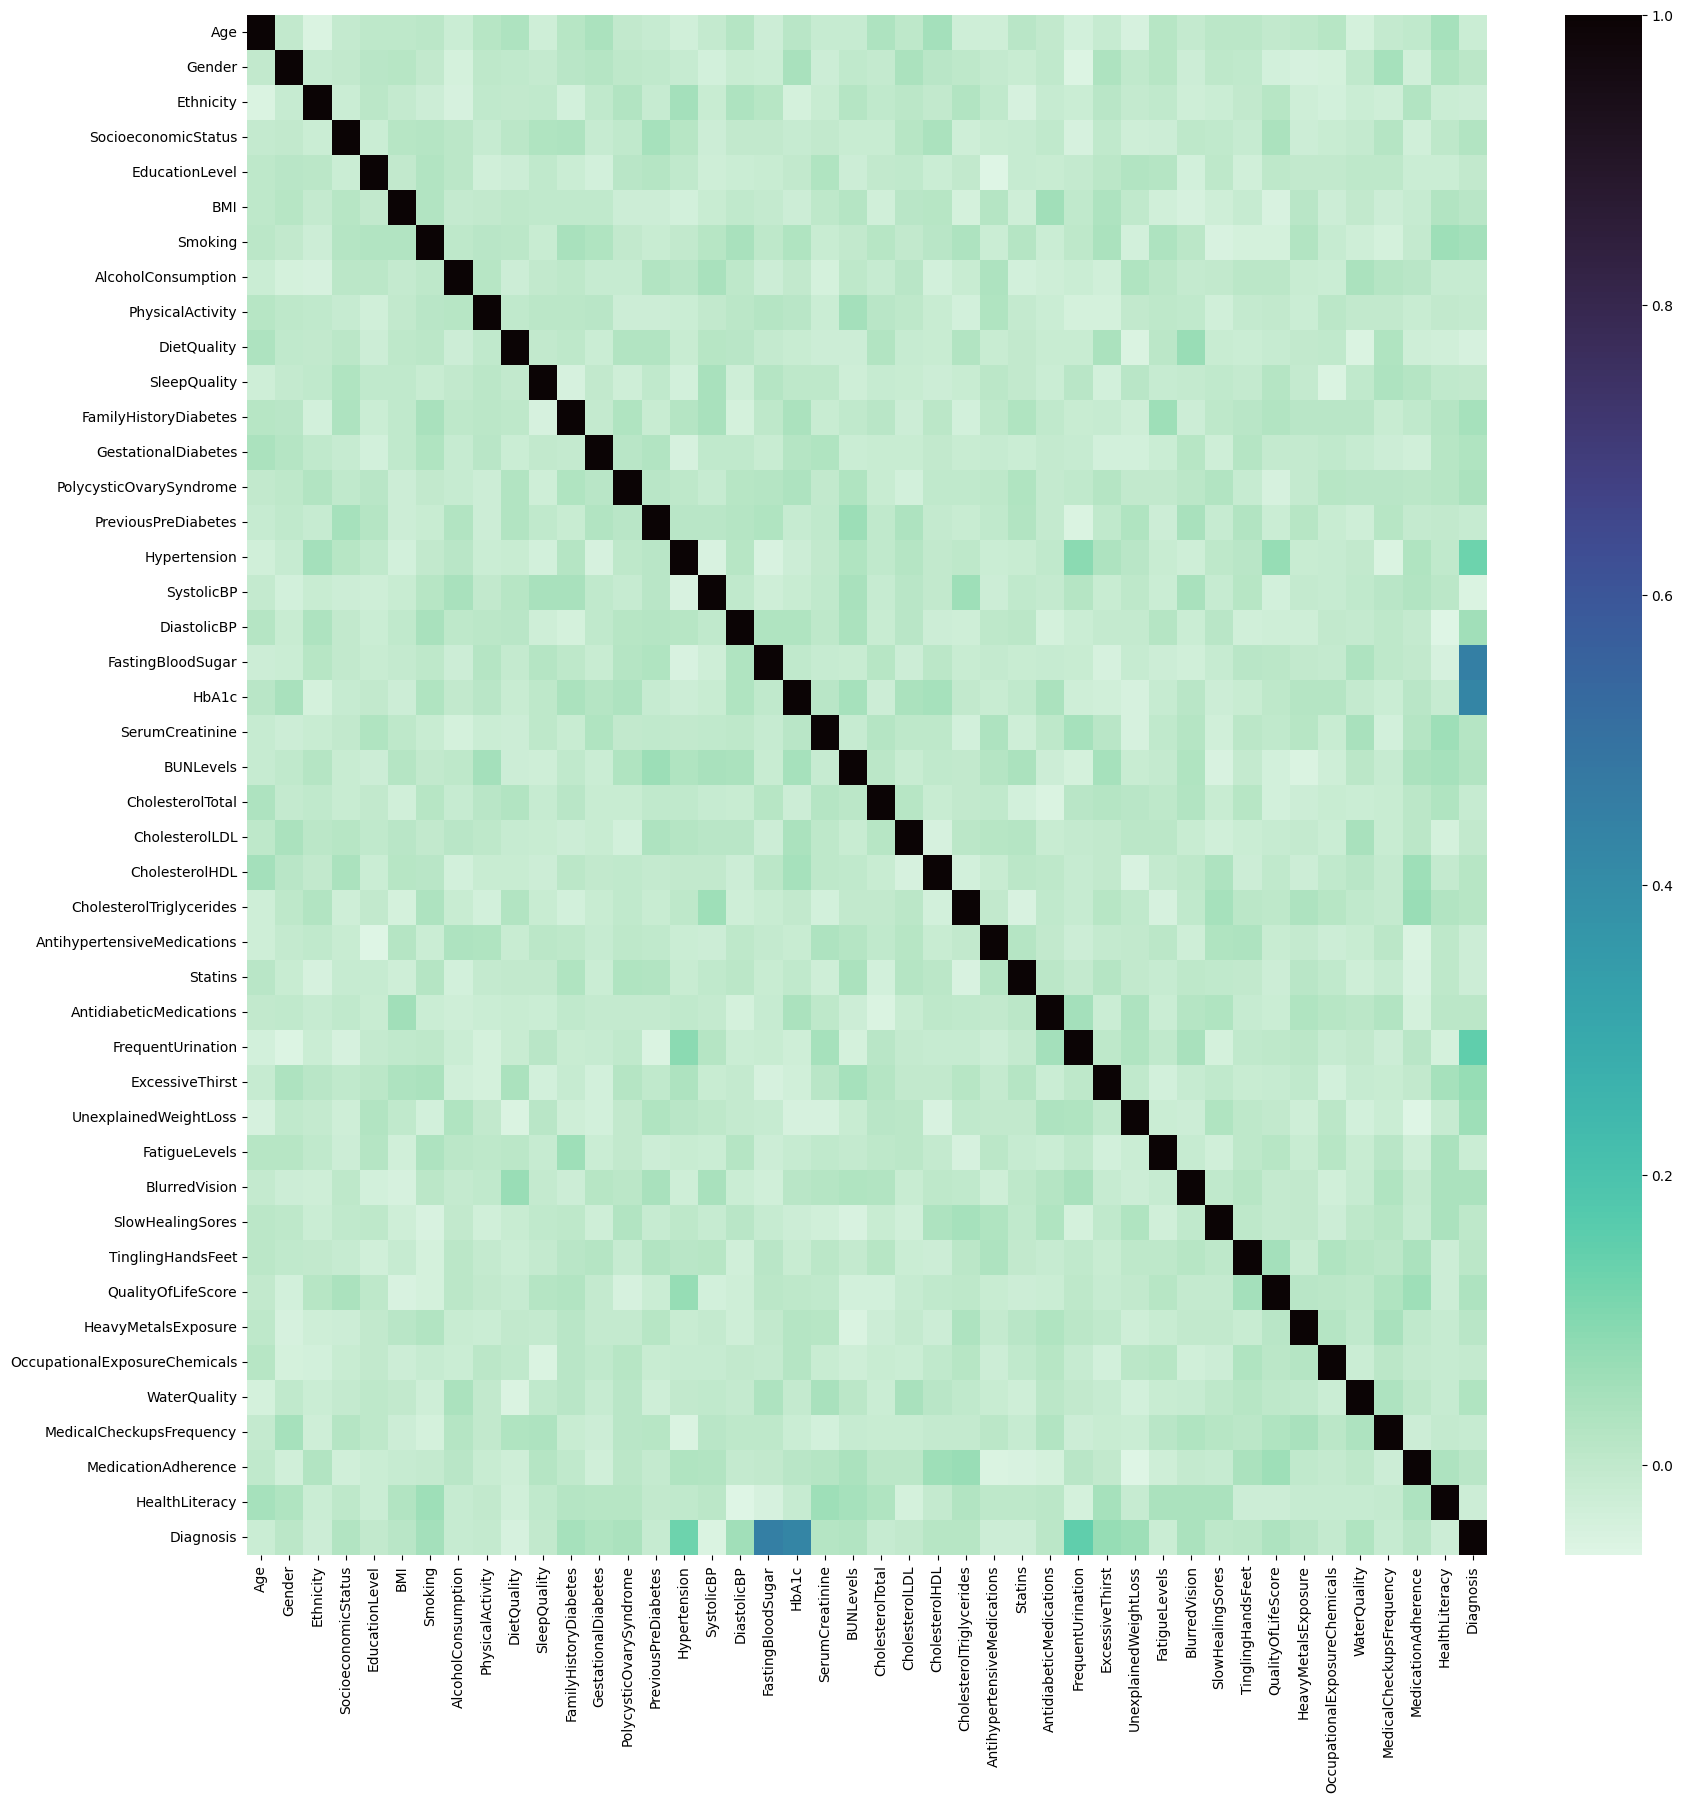

In [38]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='mako_r')
plt.savefig('plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
cor_target = abs(corr["Diagnosis"])

# Select highly correlated features (threshold = 0.1) low threshold as correlation really low
relevant_features = cor_target[cor_target > 0.1]
#( Select the features that have a correlation with the target variable (Diagnosis) greater than 0.2.)

# Collect the names of the features
names = [index for index, value in relevant_features.items()]


# Drop the target variable from the results
names.remove('Diagnosis')

# Display the results
print(names)

['Hypertension', 'FastingBloodSugar', 'HbA1c', 'FrequentUrination']


In [46]:
X = df[names]
y = df['Diagnosis']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42) #split the  data into traing and validating

In [48]:
scaler = StandardScaler() #create an instance of standard scaler
scaler.fit(X_train) # fit it to the training data

X_train = scaler.transform(X_train) #transform training data
X_test = scaler.transform(X_test) #transform validation data

In [50]:
model = LogisticRegression()

In [51]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
predictions = model.predict(X_test)

In [54]:
accuracy = accuracy_score(y_test, predictions)
print(f'the model accuracy: {accuracy}')

the model accuracy: 0.8368794326241135


In [55]:
coef = model.coef_[0]

# Put the features and their coefficients into a DataFrame
feature_importance = pd.DataFrame({
    'Feature': names,
    'Coefficient': coef,
    'Absolute_Coefficient': np.abs(coef)
})

# sort
feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(feature_importance.to_string(index=False))

          Feature  Coefficient  Absolute_Coefficient
FastingBloodSugar     1.771951              1.771951
            HbA1c     1.600919              1.600919
FrequentUrination     0.543020              0.543020
     Hypertension     0.540525              0.540525


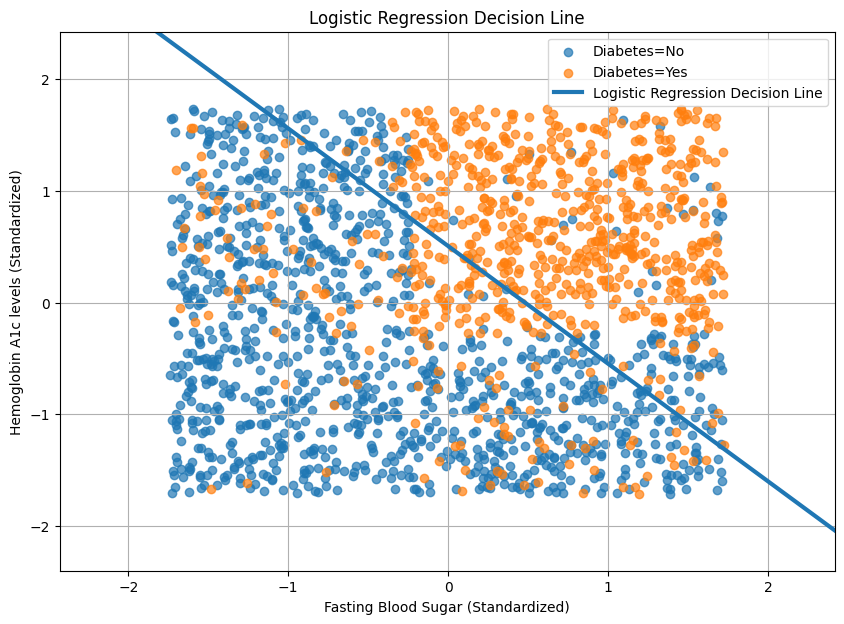

In [67]:
# 2 features we'll use in the graph
X_2d = df[['FastingBloodSugar', 'HbA1c']]
y_2d = df['Diagnosis']

# scaling
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Logistic Regression
model_2d = LogisticRegression()
model_2d.fit(X_2d_scaled, y_2d)

# dots
plt.figure(figsize=(10, 7))

plt.scatter(
    X_2d_scaled[y_2d == 0, 0],
    X_2d_scaled[y_2d == 0, 1],
    label='Diabetes=No',
    alpha=0.7
)

plt.scatter(
    X_2d_scaled[y_2d == 1, 0],
    X_2d_scaled[y_2d == 1, 1],
    label='Diabetes=Yes',
    alpha=0.7
)

# Zooming out for better view
x_min = X_2d_scaled[:, 0].min()
x_max = X_2d_scaled[:, 0].max()
y_min = X_2d_scaled[:, 1].min()
y_max = X_2d_scaled[:, 1].max()

x_padding = (x_max - x_min) * 0.2
y_padding = (y_max - y_min) * 0.2

x_min_plot = x_min - x_padding
x_max_plot = x_max + x_padding

y_min_plot = y_min - y_padding
y_max_plot = y_max + y_padding

# Values of x for the decision boundary
# Using the expanded x-axis range makes the line extend
# all the way across the visible plot
x_values = np.linspace(
    x_min_plot,
    x_max_plot,
    200
)

# b0 + b1*x1 + b2*x2 = 0
b0 = model_2d.intercept_[0]
b1 = model_2d.coef_[0][0]
b2 = model_2d.coef_[0][1]

y_values = -(b0 + b1 * x_values) / b2

plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label='Logistic Regression Decision Line'
)

plt.xlabel('Fasting Blood Sugar (Standardized)')
plt.ylabel('Hemoglobin A1c levels (Standardized)')
plt.title('Logistic Regression Decision Line')
plt.legend()
plt.grid()

plt.xlim(x_min_plot, x_max_plot)
plt.ylim(y_min_plot, y_max_plot)

# Saving
plt.savefig(
    'plots/logistic_regression_decision_line.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [75]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   logistic_regression.ipynb
	modified:   ../Multiple Linear Regression/Example 2/.ipynb_checkpoints/multiple_linear_example_2-checkpoint.ipynb
	modified:   ../Multiple Linear Regression/Example 2/multiple_linear_example_2.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
